# Приоритизация обращений — финальное решение

В этом ноутбуке представлен полный пайплайн решения задачи ранжирования обращений с использованием ансамбля моделей машинного обучения.

**Цель:** для каждого обращения предсказать вероятность целевого действия в течение 5 дней после назначения. Результат используется для ранжирования обращений (более перспективные получают более высокий score).

**Метрика:** Daily Average Precision (усреднение AP по дням).

**Основные этапы:**
1. Базовые табличные признаки (без дополнительной инженерии).
2. Инженерия признаков: отношения, разности, скользящие средние конверсий, циклические признаки времени.
3. Признаки из событий (events.csv) с агрегацией по временным окнам и статистиками по src_slot/ctx_seq.
4. Отбор признаков по встроенной важности (gain) LightGBM (95% кумулятивной важности).
5. Оптимизация гиперпараметров с помощью Optuna с временной кросс-валидацией (TimeSeriesSplit) и штрафом за переобучение.
6. Оценка лучших моделей на валидации (после тюнинга).
7. Финальное обучение на объединённых train+val и создание ансамбля (равные веса) для предсказания на тесте.

Все этапы сопровождаются сбором метрик (Train AP, Val AP) для контроля переобучения.

In [ ]:
import warnings
import lightgbm as lgb
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from catboost import CatBoostClassifier
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy.optimize import minimize
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import FunctionTransformer, Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from tqdm import tqdm

warnings.filterwarnings("ignore")

DATA_DIR = "data"
RANDOM_STATE = 42
TARGET = "target"
ID_COLS = {"lead_id", "user_id"}
TIME_COLS = {"assignment_ts", "assignment_date"}
NON_FEATURE_COLS = ID_COLS | TIME_COLS | {TARGET}

pd.set_option("display.max_colwidth", 500)
pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
optuna.logging.set_verbosity(optuna.logging.WARNING)


# Вспомогательная функция для вычисления Daily AP
def compute_daily_ap(y_true, y_pred, dates):
    aps = []
    for date in dates.unique():
        mask = dates == date
        ap = average_precision_score(y_true[mask], y_pred[mask])
        aps.append(ap)
    return np.mean(aps)


# Функция для переупорядочивания данных после трансформации
def reorder(X, source_df, target_df):
    df = pd.DataFrame(X, index=source_df.index)
    return df.loc[target_df.index].values


# Функция для преобразования numpy-массива в DataFrame с категориальными типами
def prepare_categorical_df(X, numeric_cols, cat_cols):
    df = pd.DataFrame(X, columns=numeric_cols + cat_cols)
    for col in numeric_cols:
        df[col] = df[col].astype(float)
    for col in cat_cols:
        df[col] = df[col].astype("category")
    return df


def keep_categorical(X):
    return X

## 2. Загрузка и первичный анализ данных

Загружаем обучающую выборку, тестовую выборку и события. Проверяем временные диапазоны и распределение по дням.

In [2]:
train_raw = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
events = pd.read_csv(f"{DATA_DIR}/events.csv")

train_raw["assignment_date"] = pd.to_datetime(train_raw["assignment_date"])
test["assignment_date"] = pd.to_datetime(test["assignment_date"])
events["event_ts"] = pd.to_datetime(events["event_ts"])

print("train shape:", train_raw.shape)
print("test shape:", test.shape)
print("events shape:", events.shape)
print("target mean:", train_raw[TARGET].mean())
print(
    "Train date range:",
    train_raw["assignment_date"].min(),
    "–",
    train_raw["assignment_date"].max(),
)
print(
    "Test date range:",
    test["assignment_date"].min(),
    "–",
    test["assignment_date"].max(),
)
print("Events date range:", events["event_ts"].min(), "–", events["event_ts"].max())

train_daily = train_raw.groupby("assignment_date").size()
test_daily = test.groupby("assignment_date").size()
print("Train daily counts:\n", train_daily)
print("Test daily counts:\n", test_daily)

train shape: (13694, 119)
test shape: (4306, 118)
events shape: (254705, 7)
target mean: 0.20746312253541696
Train date range: 2026-04-07 00:00:00 – 2026-04-22 00:00:00
Test date range: 2026-04-23 00:00:00 – 2026-04-27 00:00:00
Events date range: 2026-03-08 10:03:00 – 2026-04-27 20:28:00
Train daily counts:
 assignment_date
2026-04-07    873
2026-04-08    832
2026-04-09    859
2026-04-10    830
2026-04-11    861
2026-04-12    855
2026-04-13    791
2026-04-14    842
2026-04-15    899
2026-04-16    854
2026-04-17    901
2026-04-18    875
2026-04-19    863
2026-04-20    861
2026-04-21    837
2026-04-22    861
dtype: int64
Test daily counts:
 assignment_date
2026-04-23    915
2026-04-24    862
2026-04-25    818
2026-04-26    838
2026-04-27    873
dtype: int64


## 3. Базовый пайплайн (без событий)

На этом этапе используем только исходные табличные признаки. Создаём два препроцессора: с OHE (для LR) и без OHE (для бустингов с нативными категориями).

Обучаем четыре модели на базовых признаках, вычисляем метрики на валидации.

In [4]:
# Определение списков колонок
feature_columns_base = [
    col
    for col in train_raw.columns
    if col not in NON_FEATURE_COLS and col in test.columns
]
numeric_columns_base = [
    col for col in feature_columns_base if pd.api.types.is_numeric_dtype(train_raw[col])
]
categorical_columns_base = [
    col for col in feature_columns_base if col not in numeric_columns_base
]

print(f"Числовых (базовых): {len(numeric_columns_base)}")
print(f"Категориальных (базовых): {len(categorical_columns_base)}")

cutoff_date = pd.Timestamp("2026-04-20")
train_part = train_raw[train_raw["assignment_date"] < cutoff_date].copy()
valid_part = train_raw[train_raw["assignment_date"] >= cutoff_date].copy()
test_base = test.copy()


# Препроцессоры
def build_preprocessor(numeric_cols, cat_cols, use_ohe=True):
    num_trans = Pipeline(
        [("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())]
    )
    if use_ohe:
        cat_trans = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]
        )
    else:
        cat_trans = FunctionTransformer(keep_categorical, validate=False)
    return ColumnTransformer(
        [("num", num_trans, numeric_cols), ("cat", cat_trans, cat_cols)],
        remainder="drop",
    )


preprocessor_base_ohe = build_preprocessor(
    numeric_columns_base, categorical_columns_base, use_ohe=True
)
preprocessor_base_ohe.fit(train_part[feature_columns_base])
X_train_base_ohe = preprocessor_base_ohe.transform(train_part[feature_columns_base])
X_valid_base_ohe = preprocessor_base_ohe.transform(valid_part[feature_columns_base])
X_test_base_ohe = preprocessor_base_ohe.transform(test_base[feature_columns_base])

preprocessor_base_cat = build_preprocessor(
    numeric_columns_base, categorical_columns_base, use_ohe=False
)
preprocessor_base_cat.fit(train_part[feature_columns_base])
X_train_base_cat = preprocessor_base_cat.transform(train_part[feature_columns_base])
X_valid_base_cat = preprocessor_base_cat.transform(valid_part[feature_columns_base])
X_test_base_cat = preprocessor_base_cat.transform(test_base[feature_columns_base])

cat_indices_base = list(
    range(
        len(numeric_columns_base),
        len(numeric_columns_base) + len(categorical_columns_base),
    )
)

# Сортировка по датам
train_part_sorted = train_part.sort_values("assignment_date")
valid_part_sorted = valid_part.sort_values("assignment_date")
valid_dates = valid_part_sorted["assignment_date"]
y_train_sorted = train_part_sorted[TARGET].values
y_valid_sorted = valid_part_sorted[TARGET].values

X_train_base_ohe_sorted = reorder(X_train_base_ohe, train_part, train_part_sorted)
X_valid_base_ohe_sorted = reorder(X_valid_base_ohe, valid_part, valid_part_sorted)
X_train_base_cat_sorted = reorder(X_train_base_cat, train_part, train_part_sorted)
X_valid_base_cat_sorted = reorder(X_valid_base_cat, valid_part, valid_part_sorted)

daily_ap_base = {}
metrics = {}

Числовых (базовых): 107
Категориальных (базовых): 7


In [10]:
# Функция для обучения и оценки модели на этапе
def train_and_log(
    model_class,
    params,
    X_train,
    y_train,
    X_val,
    y_val,
    train_dates,
    val_dates,
    model_name,
    stage,
    extra_params=None,
):
    model = model_class(**params)
    if extra_params:
        model.fit(X_train, y_train, **extra_params)
    else:
        model.fit(X_train, y_train)
    probs_train = (
        model.predict_proba(X_train)[:, 1]
        if hasattr(model, "predict_proba")
        else model.predict(X_train)
    )
    probs_val = (
        model.predict_proba(X_val)[:, 1]
        if hasattr(model, "predict_proba")
        else model.predict(X_val)
    )
    train_ap = compute_daily_ap(y_train, probs_train, train_dates)
    val_ap = compute_daily_ap(y_val, probs_val, val_dates)
    metrics[(stage, model_name)] = (train_ap, val_ap)
    return model, train_ap, val_ap

In [11]:
# Обучаем модели на базовых признаках
# LightGBM
X_train_base_cat_df = prepare_categorical_df(
    X_train_base_cat_sorted, numeric_columns_base, categorical_columns_base
)
X_valid_base_cat_df = prepare_categorical_df(
    X_valid_base_cat_sorted, numeric_columns_base, categorical_columns_base
)
lgb_base_params = {
    "objective": "binary",
    "metric": "average_precision",
    "boosting_type": "gbdt",
    "num_leaves": 64,
    "learning_rate": 0.1,
    "n_estimators": 1000,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
    "early_stopping_rounds": 50,
    "categorical_feature": categorical_columns_base,
}
lgb_base, _, _ = train_and_log(
    lgb.LGBMClassifier,
    lgb_base_params,
    X_train_base_cat_df,
    y_train_sorted,
    X_valid_base_cat_df,
    y_valid_sorted,
    train_part_sorted["assignment_date"],
    valid_dates,
    "LightGBM",
    "base",
    {
        "eval_set": [(X_valid_base_cat_df, y_valid_sorted)],
        "callbacks": [lgb.early_stopping(50), lgb.log_evaluation(0)],
    },
)

Training until validation scores don't improve for 50 rounds


In [12]:
# XGBoost
xgb_base_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "n_estimators": 1000,
    "learning_rate": 0.1,
    "max_depth": 6,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,
    "early_stopping_rounds": 50,
    "enable_categorical": True,
}
xgb_base, _, _ = train_and_log(
    xgb.XGBClassifier,
    xgb_base_params,
    X_train_base_cat_df,
    y_train_sorted,
    X_valid_base_cat_df,
    y_valid_sorted,
    train_part_sorted["assignment_date"],
    valid_dates,
    "XGBoost",
    "base",
    {"eval_set": [(X_valid_base_cat_df, y_valid_sorted)], "verbose": False},
)

In [13]:
# CatBoost
cat_base_params = {
    "iterations": 1000,
    "learning_rate": 0.1,
    "depth": 6,
    "eval_metric": "PRAUC",
    "early_stopping_rounds": 50,
    "random_seed": RANDOM_STATE,
    "thread_count": -1,
    "verbose": 0,
    "cat_features": cat_indices_base,
}
cat_base, _, _ = train_and_log(
    CatBoostClassifier,
    cat_base_params,
    X_train_base_cat_sorted,
    y_train_sorted,
    X_valid_base_cat_sorted,
    y_valid_sorted,
    train_part_sorted["assignment_date"],
    valid_dates,
    "CatBoost",
    "base",
    {"eval_set": [(X_valid_base_cat_sorted, y_valid_sorted)], "plot": False},
)

In [14]:
# LogisticRegression
lr_base_params = {
    "penalty": "l2",
    "C": 1.0,
    "solver": "lbfgs",
    "max_iter": 1000,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}
_, _, _ = train_and_log(
    LogisticRegression,
    lr_base_params,
    X_train_base_ohe_sorted,
    y_train_sorted,
    X_valid_base_ohe_sorted,
    y_valid_sorted,
    train_part_sorted["assignment_date"],
    valid_dates,
    "LogisticRegression",
    "base",
)

In [15]:
print("\nDaily AP на базовых признаках:")
for name, ap in [(k[1], v[1]) for k, v in metrics.items() if k[0] == "base"]:
    print(f"  {name}: {ap:.5f}")


Daily AP на базовых признаках:
  LightGBM: 0.52110
  XGBoost: 0.49946
  CatBoost: 0.54344
  LogisticRegression: 0.49686


## 4. Инженерия признаков

Добавляем следующие группы признаков:
- Отношения (views per contact, favorites per view, search per view) для окон 7d, 14d, 30d, 90d.
- Разности (изменение активности) между окнами.
- Циклические признаки для часа и дня недели (sin/cos).
- Скользящие средние конверсии по категориям (регион, источник, канал) для окон 7, 14, 30 дней.

Эти признаки должны улучшить качество моделей, так как они отражают динамику поведения пользователя.

In [16]:
# Копируем данные для инженерии
train_part_eng = train_part.copy()
valid_part_eng = valid_part.copy()
test_eng = test_base.copy()

# Отношения
for df in [train_part_eng, valid_part_eng, test_eng]:
    for w in ["7d", "14d", "30d", "90d"]:
        df[f"views_per_contact_{w}"] = df[f"item_views_{w}"] / (
            df[f"user_contacts_{w}"] + 1
        )
        df[f"favorites_per_view_{w}"] = df[f"item_favorites_{w}"] / (
            df[f"item_views_{w}"] + 1
        )
        df[f"search_per_view_{w}"] = df[f"search_views_{w}"] / (
            df[f"item_views_{w}"] + 1
        )

# Разности
for df in [train_part_eng, valid_part_eng, test_eng]:
    df["views_change_7d_1d"] = df["item_views_7d"] - df["item_views_1d"]
    df["views_change_30d_7d"] = df["item_views_30d"] - df["item_views_7d"]
    df["views_change_14d_7d"] = df["item_views_14d"] - df["item_views_7d"]
    df["views_change_30d_14d"] = df["item_views_30d"] - df["item_views_14d"]
    df["contacts_change_7d_1d"] = df["user_contacts_7d"] - df["user_contacts_1d"]
    df["contacts_change_14d_7d"] = df["user_contacts_14d"] - df["user_contacts_7d"]
    df["favorites_change_7d_1d"] = df["item_favorites_7d"] - df["item_favorites_1d"]
    df["favorites_change_14d_7d"] = df["item_favorites_14d"] - df["item_favorites_7d"]

# Циклические признаки
for df in [train_part_eng, valid_part_eng, test_eng]:
    df["hour_sin"] = np.sin(2 * np.pi * df["assignment_hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["assignment_hour"] / 24)
    df["weekday_sin"] = np.sin(2 * np.pi * df["assignment_weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["assignment_weekday"] / 7)


# Скользящие средние конверсии
def add_rolling_conv(df, cat_col, window):
    df_sorted = df.sort_values("assignment_date")
    result = []
    global_mean = df_sorted["target"].mean()
    for date in df_sorted["assignment_date"].unique():
        past_mask = (
            df_sorted["assignment_date"] >= date - pd.Timedelta(days=window)
        ) & (df_sorted["assignment_date"] < date)
        past = df_sorted[past_mask]
        if past.empty:
            conv_dict = dict.fromkeys(df_sorted[cat_col].unique(), global_mean)
        else:
            conv_dict = past.groupby(cat_col)["target"].mean().to_dict()
            for cat in df_sorted[cat_col].unique():
                if cat not in conv_dict:
                    conv_dict[cat] = global_mean
        for idx in df_sorted[df_sorted["assignment_date"] == date].index:
            cat_val = df_sorted.loc[idx, cat_col]
            result.append(
                {
                    "index": idx,
                    f"{cat_col}_conv_{window}d": conv_dict.get(cat_val, global_mean),
                }
            )
    return pd.DataFrame(result).set_index("index")


for window in [7, 14, 30]:
    for cat in ["region", "lead_source", "lead_channel"]:
        conv_df = add_rolling_conv(train_part_eng, cat, window)
        train_part_eng = train_part_eng.join(conv_df)
        global_conv = train_part_eng.groupby(cat)["target"].mean().to_dict()
        global_mean = train_part_eng["target"].mean()
        for df in [valid_part_eng, test_eng]:
            df[f"{cat}_conv_{window}d"] = df[cat].map(global_conv).fillna(global_mean)

feature_columns_eng = [
    col
    for col in train_part_eng.columns
    if col not in NON_FEATURE_COLS and col in test_eng.columns
]
numeric_columns_eng = [
    col
    for col in feature_columns_eng
    if pd.api.types.is_numeric_dtype(train_part_eng[col])
]
categorical_columns_eng = [
    col for col in feature_columns_eng if col not in numeric_columns_eng
]

print(f"Числовых (с инженерией): {len(numeric_columns_eng)}")
print(f"Категориальных (с инженерией): {len(categorical_columns_eng)}")

Числовых (с инженерией): 140
Категориальных (с инженерией): 7


### 4.1 Обучение на базе + инженерия
Повторяем процедуру обучения с новыми признаками, фиксируем улучшение метрик.

In [17]:
preprocessor_eng_ohe = build_preprocessor(
    numeric_columns_eng, categorical_columns_eng, use_ohe=True
)
preprocessor_eng_ohe.fit(train_part_eng[feature_columns_eng])
X_train_eng_ohe = preprocessor_eng_ohe.transform(train_part_eng[feature_columns_eng])
X_valid_eng_ohe = preprocessor_eng_ohe.transform(valid_part_eng[feature_columns_eng])
X_test_eng_ohe = preprocessor_eng_ohe.transform(test_eng[feature_columns_eng])

preprocessor_eng_cat = build_preprocessor(
    numeric_columns_eng, categorical_columns_eng, use_ohe=False
)
preprocessor_eng_cat.fit(train_part_eng[feature_columns_eng])
X_train_eng_cat = preprocessor_eng_cat.transform(train_part_eng[feature_columns_eng])
X_valid_eng_cat = preprocessor_eng_cat.transform(valid_part_eng[feature_columns_eng])
X_test_eng_cat = preprocessor_eng_cat.transform(test_eng[feature_columns_eng])

cat_indices_eng = list(
    range(
        len(numeric_columns_eng),
        len(numeric_columns_eng) + len(categorical_columns_eng),
    )
)

train_part_eng_sorted = train_part_eng.sort_values("assignment_date")
valid_part_eng_sorted = valid_part_eng.sort_values("assignment_date")
y_train_eng_sorted = train_part_eng_sorted[TARGET].values
y_valid_eng_sorted = valid_part_eng_sorted[TARGET].values
valid_dates_eng = valid_part_eng_sorted["assignment_date"]

X_train_eng_ohe_sorted = reorder(X_train_eng_ohe, train_part_eng, train_part_eng_sorted)
X_valid_eng_ohe_sorted = reorder(X_valid_eng_ohe, valid_part_eng, valid_part_eng_sorted)
X_train_eng_cat_sorted = reorder(X_train_eng_cat, train_part_eng, train_part_eng_sorted)
X_valid_eng_cat_sorted = reorder(X_valid_eng_cat, valid_part_eng, valid_part_eng_sorted)

In [18]:
# LightGBM
X_train_eng_cat_df = prepare_categorical_df(
    X_train_eng_cat_sorted, numeric_columns_eng, categorical_columns_eng
)
X_valid_eng_cat_df = prepare_categorical_df(
    X_valid_eng_cat_sorted, numeric_columns_eng, categorical_columns_eng
)
lgb_eng_params = lgb_base_params.copy()
lgb_eng_params["categorical_feature"] = categorical_columns_eng
train_and_log(
    lgb.LGBMClassifier,
    lgb_eng_params,
    X_train_eng_cat_df,
    y_train_eng_sorted,
    X_valid_eng_cat_df,
    y_valid_eng_sorted,
    train_part_eng_sorted["assignment_date"],
    valid_dates_eng,
    "LightGBM",
    "eng",
    {
        "eval_set": [(X_valid_eng_cat_df, y_valid_eng_sorted)],
        "callbacks": [lgb.early_stopping(50), lgb.log_evaluation(0)],
    },
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[161]	valid_0's average_precision: 0.501323


(LGBMClassifier(categorical_feature=['lead_source', 'call_center', 'region',
                                     'car_segment', 'lead_channel',
                                     'user_tenure_bucket', 'price_bucket'],
                early_stopping_rounds=50, metric='average_precision',
                n_estimators=1000, n_jobs=-1, num_leaves=64, objective='binary',
                random_state=42, verbose=-1),
 np.float64(1.0),
 np.float64(0.5086111904997551))

In [19]:
# XGBoost
xgb_eng_params = xgb_base_params.copy()
train_and_log(
    xgb.XGBClassifier,
    xgb_eng_params,
    X_train_eng_cat_df,
    y_train_eng_sorted,
    X_valid_eng_cat_df,
    y_valid_eng_sorted,
    train_part_eng_sorted["assignment_date"],
    valid_dates_eng,
    "XGBoost",
    "eng",
    {"eval_set": [(X_valid_eng_cat_df, y_valid_eng_sorted)], "verbose": False},
)


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=1.0, device=None, early_stopping_rounds=50,
               enable_categorical=True, eval_metric='auc', feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.1, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=1000,
               n_jobs=-1, num_parallel_tree=None, ...),
 np.float64(0.9351866003738161),
 np.float64(0.49830618030033563))

In [20]:
# CatBoost
cat_eng_params = cat_base_params.copy()
cat_eng_params["cat_features"] = cat_indices_eng
train_and_log(
    CatBoostClassifier,
    cat_eng_params,
    X_train_eng_cat_sorted,
    y_train_eng_sorted,
    X_valid_eng_cat_sorted,
    y_valid_eng_sorted,
    train_part_eng_sorted["assignment_date"],
    valid_dates_eng,
    "CatBoost",
    "eng",
    {"eval_set": [(X_valid_eng_cat_sorted, y_valid_eng_sorted)], "plot": False},
)

(CatBoostClassifier(cat_features=[140, 141, 142, 143, 144, 145, 146], depth=6, early_stopping_rounds=50, eval_metric='PRAUC', iterations=1000, learning_rate=0.1, random_seed=42, verbose=0),
 np.float64(0.9179171188460313),
 np.float64(0.5311902518293884))

In [21]:
# LogisticRegression
train_and_log(
    LogisticRegression,
    lr_base_params,
    X_train_eng_ohe_sorted,
    y_train_eng_sorted,
    X_valid_eng_ohe_sorted,
    y_valid_eng_sorted,
    train_part_eng_sorted["assignment_date"],
    valid_dates_eng,
    "LogisticRegression",
    "eng",
)

(LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42),
 np.float64(0.4936849620162983),
 np.float64(0.49261197687831615))

In [22]:
print("\nDaily AP на базе + инженерия:")
for name, ap in [(k[1], v[1]) for k, v in metrics.items() if k[0] == "eng"]:
    print(f"  {name}: {ap:.5f}")


Daily AP на базе + инженерия:
  LightGBM: 0.50861
  XGBoost: 0.49831
  CatBoost: 0.53119
  LogisticRegression: 0.49261


## 5. Признаки из событий

Из событий (events.csv) строим агрегации по временным окнам: 15 мин, 1 час, 3 часа, 6 часов, 24 часа. Для каждого окна считаем общее число событий и число событий каждого типа. Также вычисляем время с последнего события каждого типа, разнообразие типов за 24 часа, бинарные флаги наличия события за 2 часа. Дополнительно добавляем статистики по полям src_slot (среднее, std, min, max) и число уникальных ctx_seq.

Важно: используем только события с event_ts < assignment_ts, чтобы избежать утечки.

In [23]:
EVENT_TYPES = ["item_view", "search", "favorite", "chat_open", "call_click"]
WINDOWS = {"15m": 15, "1h": 60, "3h": 180, "6h": 360, "24h": 1440}


def build_event_features(df_objects, events):
    events = events.copy()
    df_objects = df_objects.copy()
    df_objects["assignment_ts"] = pd.to_datetime(df_objects["assignment_ts"])
    grouped = events.sort_values(["lead_id", "event_ts"]).groupby("lead_id")
    records = []
    for lead_id, assign_ts in tqdm(
        df_objects[["lead_id", "assignment_ts"]].values,
        total=len(df_objects),
        desc="Events",
    ):
        rec = {"lead_id": lead_id}
        past = (
            grouped.get_group(lead_id) if lead_id in grouped.groups else pd.DataFrame()
        )
        past = past[past["event_ts"] < assign_ts] if not past.empty else past
        if past.empty:
            for w in WINDOWS:
                rec[f"event_count_{w}"] = 0
                for t in EVENT_TYPES:
                    rec[f"{t}_{w}"] = 0
            rec["time_since_last_event"] = 86400
            for t in EVENT_TYPES:
                rec[f"time_since_last_{t}"] = 86400
            rec["unique_types_24h"] = 0
            for t in EVENT_TYPES:
                rec[f"has_{t}_2h"] = 0
            rec["event_mean_src_slot"] = 0
            rec["event_std_src_slot"] = 0
            rec["event_min_src_slot"] = 0
            rec["event_max_src_slot"] = 0
            rec["event_unique_ctx_seq"] = 0
            records.append(rec)
            continue
        windows_ts = {
            w: assign_ts - pd.Timedelta(minutes=m) for w, m in WINDOWS.items()
        }
        for w, start in windows_ts.items():
            window_events = past[past["event_ts"] >= start]
            rec[f"event_count_{w}"] = len(window_events)
            for t in EVENT_TYPES:
                rec[f"{t}_{w}"] = (window_events["event_type"] == t).sum()
        rec["time_since_last_event"] = (
            assign_ts - past["event_ts"].max()
        ).total_seconds()
        for t in EVENT_TYPES:
            type_events = past[past["event_type"] == t]
            rec[f"time_since_last_{t}"] = (
                (assign_ts - type_events["event_ts"].max()).total_seconds()
                if not type_events.empty
                else 86400
            )
        rec["unique_types_24h"] = past[past["event_ts"] >= windows_ts["24h"]][
            "event_type"
        ].nunique()
        recent_2h = past[past["event_ts"] >= assign_ts - pd.Timedelta(hours=2)]
        for t in EVENT_TYPES:
            rec[f"has_{t}_2h"] = int((recent_2h["event_type"] == t).any())
        rec["event_mean_src_slot"] = past["src_slot"].mean() if not past.empty else 0
        rec["event_std_src_slot"] = past["src_slot"].std() if len(past) > 1 else 0
        rec["event_min_src_slot"] = past["src_slot"].min() if not past.empty else 0
        rec["event_max_src_slot"] = past["src_slot"].max() if not past.empty else 0
        rec["event_unique_ctx_seq"] = past["ctx_seq"].nunique()
        records.append(rec)
    return pd.DataFrame(records)

In [24]:
train_events_feat = build_event_features(
    train_part_eng[["lead_id", "assignment_ts"]], events
)
valid_events_feat = build_event_features(
    valid_part_eng[["lead_id", "assignment_ts"]], events
)
test_events_feat = build_event_features(test_eng[["lead_id", "assignment_ts"]], events)

train_with_events = train_part_eng.merge(train_events_feat, on="lead_id", how="left")
valid_with_events = valid_part_eng.merge(valid_events_feat, on="lead_id", how="left")
test_with_events = test_eng.merge(test_events_feat, on="lead_id", how="left")

new_feat_cols = [col for col in train_events_feat.columns if col != "lead_id"]
for df in [train_with_events, valid_with_events, test_with_events]:
    df[new_feat_cols] = df[new_feat_cols].fillna(0)

Events: 100%|██████████| 4306/4306 [00:48<00:00, 88.03it/s] 


In [25]:
print("Размер train после слияния:", train_with_events.shape)
print("Размер valid после слияния:", valid_with_events.shape)
print("Размер test после слияния:", test_with_events.shape)

Размер train после слияния: (11135, 199)
Размер valid после слияния: (2559, 199)
Размер test после слияния: (4306, 198)


In [26]:
assert train_with_events[new_feat_cols].isnull().sum().sum() == 0
assert valid_with_events[new_feat_cols].isnull().sum().sum() == 0
assert test_with_events[new_feat_cols].isnull().sum().sum() == 0
print("Пропуски в новых признаках отсутствуют.")

Пропуски в новых признаках отсутствуют.


### 5.1 Обучение на признаках с событиями
Включаем все признаки (исходные + инженерия + события) и повторяем обучение.

In [27]:
feature_columns = [
    col for col in train_with_events.columns if col not in NON_FEATURE_COLS
]
numeric_columns = [
    col
    for col in feature_columns
    if pd.api.types.is_numeric_dtype(train_with_events[col])
]
categorical_columns = [col for col in feature_columns if col not in numeric_columns]
print(
    f"Всего признаков: {len(feature_columns)}, числовых: {len(numeric_columns)}, категориальных: {len(categorical_columns)}"
)

train_part_events = train_with_events[
    train_with_events["assignment_date"] < cutoff_date
].copy()
valid_part_events = valid_with_events[
    valid_with_events["assignment_date"] >= cutoff_date
].copy()
test_part_events = test_with_events.copy()

preprocessor_events_ohe = build_preprocessor(
    numeric_columns, categorical_columns, use_ohe=True
)
preprocessor_events_ohe.fit(train_part_events[feature_columns])
X_train_events_ohe = preprocessor_events_ohe.transform(
    train_part_events[feature_columns]
)
X_valid_events_ohe = preprocessor_events_ohe.transform(
    valid_part_events[feature_columns]
)
X_test_events_ohe = preprocessor_events_ohe.transform(test_part_events[feature_columns])

preprocessor_events_cat = build_preprocessor(
    numeric_columns, categorical_columns, use_ohe=False
)
preprocessor_events_cat.fit(train_part_events[feature_columns])
X_train_events_cat = preprocessor_events_cat.transform(
    train_part_events[feature_columns]
)
X_valid_events_cat = preprocessor_events_cat.transform(
    valid_part_events[feature_columns]
)
X_test_events_cat = preprocessor_events_cat.transform(test_part_events[feature_columns])

cat_indices_events = list(
    range(len(numeric_columns), len(numeric_columns) + len(categorical_columns))
)

train_part_events_sorted = train_part_events.sort_values("assignment_date")
valid_part_events_sorted = valid_part_events.sort_values("assignment_date")
y_train_events_sorted = train_part_events_sorted[TARGET].values
y_valid_events_sorted = valid_part_events_sorted[TARGET].values
valid_dates_events = valid_part_events_sorted["assignment_date"]

X_train_events_ohe_sorted = reorder(
    X_train_events_ohe, train_part_events, train_part_events_sorted
)
X_valid_events_ohe_sorted = reorder(
    X_valid_events_ohe, valid_part_events, valid_part_events_sorted
)
X_train_events_cat_sorted = reorder(
    X_train_events_cat, train_part_events, train_part_events_sorted
)
X_valid_events_cat_sorted = reorder(
    X_valid_events_cat, valid_part_events, valid_part_events_sorted
)

Всего признаков: 194, числовых: 187, категориальных: 7


In [28]:
# LightGBM
X_train_events_cat_df = prepare_categorical_df(
    X_train_events_cat_sorted, numeric_columns, categorical_columns
)
X_valid_events_cat_df = prepare_categorical_df(
    X_valid_events_cat_sorted, numeric_columns, categorical_columns
)
lgb_events_params = lgb_base_params.copy()
lgb_events_params["categorical_feature"] = categorical_columns
train_and_log(
    lgb.LGBMClassifier,
    lgb_events_params,
    X_train_events_cat_df,
    y_train_events_sorted,
    X_valid_events_cat_df,
    y_valid_events_sorted,
    train_part_events_sorted["assignment_date"],
    valid_dates_events,
    "LightGBM",
    "events",
    {
        "eval_set": [(X_valid_events_cat_df, y_valid_events_sorted)],
        "callbacks": [lgb.early_stopping(50), lgb.log_evaluation(0)],
    },
)

Training until validation scores don't improve for 50 rounds


(LGBMClassifier(categorical_feature=['lead_source', 'call_center', 'region',
                                     'car_segment', 'lead_channel',
                                     'user_tenure_bucket', 'price_bucket'],
                early_stopping_rounds=50, metric='average_precision',
                n_estimators=1000, n_jobs=-1, num_leaves=64, objective='binary',
                random_state=42, verbose=-1),
 np.float64(1.0),
 np.float64(0.6471750419884679))

In [29]:
# XGBoost
xgb_events_params = xgb_base_params.copy()
train_and_log(
    xgb.XGBClassifier,
    xgb_events_params,
    X_train_events_cat_df,
    y_train_events_sorted,
    X_valid_events_cat_df,
    y_valid_events_sorted,
    train_part_events_sorted["assignment_date"],
    valid_dates_events,
    "XGBoost",
    "events",
    {"eval_set": [(X_valid_events_cat_df, y_valid_events_sorted)], "verbose": False},
)

(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=1.0, device=None, early_stopping_rounds=50,
               enable_categorical=True, eval_metric='auc', feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.1, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=1000,
               n_jobs=-1, num_parallel_tree=None, ...),
 np.float64(0.999967639722241),
 np.float64(0.6530481858131062))

In [30]:
# CatBoost
cat_events_params = cat_base_params.copy()
cat_events_params["cat_features"] = cat_indices_events
train_and_log(
    CatBoostClassifier,
    cat_events_params,
    X_train_events_cat_sorted,
    y_train_events_sorted,
    X_valid_events_cat_sorted,
    y_valid_events_sorted,
    train_part_events_sorted["assignment_date"],
    valid_dates_events,
    "CatBoost",
    "events",
    {"eval_set": [(X_valid_events_cat_sorted, y_valid_events_sorted)], "plot": False},
)

(CatBoostClassifier(cat_features=[187, 188, 189, 190, 191, 192, 193], depth=6, early_stopping_rounds=50, eval_metric='PRAUC', iterations=1000, learning_rate=0.1, random_seed=42, verbose=0),
 np.float64(0.9241884428290538),
 np.float64(0.6398991982382917))

In [31]:
# LogisticRegression
train_and_log(
    LogisticRegression,
    lr_base_params,
    X_train_events_ohe_sorted,
    y_train_events_sorted,
    X_valid_events_ohe_sorted,
    y_valid_events_sorted,
    train_part_events_sorted["assignment_date"],
    valid_dates_events,
    "LogisticRegression",
    "events",
)

(LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42),
 np.float64(0.5799178809584055),
 np.float64(0.5804439038354814))

In [32]:
print("\nDaily AP на признаках с событиями:")
for name, ap in [(k[1], v[1]) for k, v in metrics.items() if k[0] == "events"]:
    print(f"  {name}: {ap:.5f}")


Daily AP на признаках с событиями:
  LightGBM: 0.64718
  XGBoost: 0.65305
  CatBoost: 0.63990
  LogisticRegression: 0.58044


## 6. Отбор признаков по важности (gain) LightGBM
Обучаем LightGBM на данных с событиями (без кросс-валидации, только для оценки важности). Вычисляем важность типа 'gain' (вклад признака в уменьшение ошибки) и отбираем признаки, покрывающие 95% кумулятивной важности. Это позволяет сократить размерность и уменьшить шум, что должно улучшить обобщение.

После отбора создаём новые препроцессоры только на отобранных признаках и повторно оцениваем модели (этап selected).

In [33]:
X_train_importance_df = prepare_categorical_df(
    X_train_events_cat_sorted, numeric_columns, categorical_columns
)
lgb_importance = lgb.LGBMClassifier(
    objective="binary",
    metric="average_precision",
    num_leaves=64,
    learning_rate=0.1,
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    categorical_feature=categorical_columns,
)
lgb_importance.fit(X_train_importance_df, y_train_events_sorted)

importance_gain = lgb_importance.booster_.feature_importance(importance_type="gain")
feature_names_cat = numeric_columns + categorical_columns
imp_df = pd.DataFrame(
    {"feature": feature_names_cat, "importance": importance_gain}
).sort_values("importance", ascending=False)
cumsum = imp_df["importance"].cumsum()
total = cumsum.iloc[-1]
n_selected = (cumsum / total <= 0.95).sum() + 1
selected_features = imp_df.head(n_selected)["feature"].values
selected_numeric = [f for f in selected_features if f in numeric_columns]
selected_categorical = [f for f in selected_features if f in categorical_columns]
print(
    f"Отобрано {len(selected_features)} признаков из {len(feature_names_cat)} (95% важности gain)"
)
print(
    f"Числовых отобрано: {len(selected_numeric)}, категориальных: {len(selected_categorical)}"
)

Отобрано 99 признаков из 194 (95% важности gain)
Числовых отобрано: 96, категориальных: 3


In [34]:
preprocessor_sel_ohe = build_preprocessor(
    selected_numeric, selected_categorical, use_ohe=True
)
preprocessor_sel_cat = build_preprocessor(
    selected_numeric, selected_categorical, use_ohe=False
)
preprocessor_sel_ohe.fit(train_part_events[feature_columns])
preprocessor_sel_cat.fit(train_part_events[feature_columns])

X_train_sel_ohe = preprocessor_sel_ohe.transform(train_part_events[feature_columns])
X_valid_sel_ohe = preprocessor_sel_ohe.transform(valid_part_events[feature_columns])
X_test_sel_ohe = preprocessor_sel_ohe.transform(test_part_events[feature_columns])

X_train_sel_cat = preprocessor_sel_cat.transform(train_part_events[feature_columns])
X_valid_sel_cat = preprocessor_sel_cat.transform(valid_part_events[feature_columns])
X_test_sel_cat = preprocessor_sel_cat.transform(test_part_events[feature_columns])

cat_indices_sel = list(
    range(len(selected_numeric), len(selected_numeric) + len(selected_categorical))
)

train_part_sel_sorted = train_part_events.sort_values("assignment_date")
valid_part_sel_sorted = valid_part_events.sort_values("assignment_date")
y_train_sel_sorted = train_part_sel_sorted[TARGET].values
y_valid_sel_sorted = valid_part_sel_sorted[TARGET].values
valid_dates_sel = valid_part_sel_sorted["assignment_date"]

X_train_sel_ohe_sorted = reorder(
    X_train_sel_ohe, train_part_events, train_part_sel_sorted
)
X_valid_sel_ohe_sorted = reorder(
    X_valid_sel_ohe, valid_part_events, valid_part_sel_sorted
)
X_train_sel_cat_sorted = reorder(
    X_train_sel_cat, train_part_events, train_part_sel_sorted
)
X_valid_sel_cat_sorted = reorder(
    X_valid_sel_cat, valid_part_events, valid_part_sel_sorted
)

print(f"Размерность отобранных признаков (OHE): {X_train_sel_ohe_sorted.shape[1]}")
print(f"Размерность отобранных признаков (сырые): {X_train_sel_cat_sorted.shape[1]}")

Размерность отобранных признаков (OHE): 104
Размерность отобранных признаков (сырые): 99


In [35]:
# Оценка на отобранных признаках
X_train_sel_cat_df = prepare_categorical_df(
    X_train_sel_cat_sorted, selected_numeric, selected_categorical
)
X_valid_sel_cat_df = prepare_categorical_df(
    X_valid_sel_cat_sorted, selected_numeric, selected_categorical
)

In [36]:
# LightGBM
lgb_sel_params = {
    "objective": "binary",
    "metric": "average_precision",
    "boosting_type": "gbdt",
    "num_leaves": 32,
    "learning_rate": 0.1,
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
    "categorical_feature": selected_categorical,
}
train_and_log(
    lgb.LGBMClassifier,
    lgb_sel_params,
    X_train_sel_cat_df,
    y_train_sel_sorted,
    X_valid_sel_cat_df,
    y_valid_sel_sorted,
    train_part_sel_sorted["assignment_date"],
    valid_dates_sel,
    "LightGBM",
    "selected",
)

(LGBMClassifier(categorical_feature=['lead_source', 'user_tenure_bucket',
                                     'call_center'],
                metric='average_precision', n_estimators=500, n_jobs=-1,
                num_leaves=32, objective='binary', random_state=42, verbose=-1),
 np.float64(1.0),
 np.float64(0.6500322449073973))

In [37]:
# XGBoost
xgb_sel_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "n_estimators": 500,
    "learning_rate": 0.1,
    "max_depth": 6,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,
    "enable_categorical": True,
}
train_and_log(
    xgb.XGBClassifier,
    xgb_sel_params,
    X_train_sel_cat_df,
    y_train_sel_sorted,
    X_valid_sel_cat_df,
    y_valid_sel_sorted,
    train_part_sel_sorted["assignment_date"],
    valid_dates_sel,
    "XGBoost",
    "selected",
)

(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=1.0, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric='auc', feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.1, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=500,
               n_jobs=-1, num_parallel_tree=None, ...),
 np.float64(1.0),
 np.float64(0.6407800656282093))

In [38]:
# CatBoost
cat_sel_params = {
    "iterations": 500,
    "learning_rate": 0.1,
    "depth": 6,
    "eval_metric": "PRAUC",
    "random_seed": RANDOM_STATE,
    "thread_count": -1,
    "verbose": 0,
    "cat_features": cat_indices_sel,
}
train_and_log(
    CatBoostClassifier,
    cat_sel_params,
    X_train_sel_cat_sorted,
    y_train_sel_sorted,
    X_valid_sel_cat_sorted,
    y_valid_sel_sorted,
    train_part_sel_sorted["assignment_date"],
    valid_dates_sel,
    "CatBoost",
    "selected",
)

(CatBoostClassifier(cat_features=[96, 97, 98], depth=6, eval_metric='PRAUC', iterations=500, learning_rate=0.1, random_seed=42, verbose=0),
 np.float64(0.9912749907582937),
 np.float64(0.6556602276374556))

In [39]:
# LogisticRegression
scaler_sel = RobustScaler()
X_train_sel_ohe_scaled = scaler_sel.fit_transform(X_train_sel_ohe_sorted)
X_valid_sel_ohe_scaled = scaler_sel.transform(X_valid_sel_ohe_sorted)
lr_sel_params = {
    "penalty": "l2",
    "C": 1.0,
    "solver": "lbfgs",
    "max_iter": 1000,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}
train_and_log(
    LogisticRegression,
    lr_sel_params,
    X_train_sel_ohe_scaled,
    y_train_sel_sorted,
    X_valid_sel_ohe_scaled,
    y_valid_sel_sorted,
    train_part_sel_sorted["assignment_date"],
    valid_dates_sel,
    "LogisticRegression",
    "selected",
)

(LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42),
 np.float64(0.5593352888424068),
 np.float64(0.5737575076719491))

In [40]:
print("\nDaily AP на отобранных признаках:")
for name, ap in [(k[1], v[1]) for k, v in metrics.items() if k[0] == "selected"]:
    print(f"  {name}: {ap:.5f}")


Daily AP на отобранных признаках:
  LightGBM: 0.65003
  XGBoost: 0.64078
  CatBoost: 0.65566
  LogisticRegression: 0.57376


## 7. Оптимизация гиперпараметров с помощью Optuna

Для каждой модели проводим поиск гиперпараметров с использованием временной кросс-валидации (TimeSeriesSplit, n_splits=5) и целевой функции, которая штрафует переобучение (loss = -val_ap + alpha * (train_ap - val_ap), где alpha=0.35).

Это позволяет выбрать параметры, которые хорошо работают на временной структуре данных и не переобучаются.

В результате получаем лучшие параметры, которые будут использованы для финального обучения.

In [41]:
# tscv = TimeSeriesSplit(n_splits=5, gap=0)

# # Определяем функции objective для каждой модели
# def objective_lgb(trial):
#     params = {
#         'objective': 'binary',
#         'metric': 'average_precision',
#         'boosting_type': 'gbdt',
#         'num_leaves': trial.suggest_int('num_leaves', 8, 28),
#         'learning_rate': trial.suggest_float('learning_rate', 0.008, 0.08, log=True),
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1500),
#         'min_child_samples': trial.suggest_int('min_child_samples', 40, 120),
#         'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 0.5),
#         'subsample': trial.suggest_float('subsample', 0.45, 0.85),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.45, 0.85),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.5, 15.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 15.0, log=True),
#         'random_state': RANDOM_STATE,
#         'n_jobs': -1,
#         'verbose': -1,
#         'early_stopping_rounds': 50,
#         'categorical_feature': selected_categorical
#     }
#     scores = []
#     alpha = 0.35
#     for train_idx, valid_idx in tscv.split(X_train_sel_cat_sorted):
#         X_tr = X_train_sel_cat_sorted[train_idx]
#         X_val = X_train_sel_cat_sorted[valid_idx]
#         y_tr = y_train_sel_sorted[train_idx]
#         y_val = y_train_sel_sorted[valid_idx]
#         train_dates = train_part_sel_sorted.iloc[train_idx]['assignment_date']
#         valid_dates = train_part_sel_sorted.iloc[valid_idx]['assignment_date']
#         X_tr_df = prepare_categorical_df(X_tr, selected_numeric, selected_categorical)
#         X_val_df = prepare_categorical_df(X_val, selected_numeric, selected_categorical)
#         clf = lgb.LGBMClassifier(**params)
#         clf.fit(X_tr_df, y_tr, eval_set=[(X_val_df, y_val)], callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
#         probs_train = clf.predict_proba(X_tr_df)[:, 1]
#         probs_val = clf.predict_proba(X_val_df)[:, 1]
#         train_ap = compute_daily_ap(y_tr, probs_train, train_dates)
#         val_ap = compute_daily_ap(y_val, probs_val, valid_dates)
#         loss = -val_ap + alpha * (train_ap - val_ap)
#         scores.append(loss)
#     return np.mean(scores)

# def objective_xgb(trial):
#     params = {
#         'objective': 'binary:logistic',
#         'eval_metric': 'auc',
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1500),
#         'max_depth': trial.suggest_int('max_depth', 3, 6),
#         'min_child_weight': trial.suggest_int('min_child_weight', 7, 15),
#         'learning_rate': trial.suggest_float('learning_rate', 0.008, 0.08, log=True),
#         'subsample': trial.suggest_float('subsample', 0.45, 0.85),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.45, 0.85),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.5, 15.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 15.0, log=True),
#         'random_state': RANDOM_STATE,
#         'n_jobs': -1,
#         'verbosity': 0,
#         'early_stopping_rounds': 50,
#         'enable_categorical': True,
#     }
#     scores = []
#     alpha = 0.35
#     for train_idx, valid_idx in tscv.split(X_train_sel_cat_sorted):
#         X_tr = X_train_sel_cat_sorted[train_idx]
#         X_val = X_train_sel_cat_sorted[valid_idx]
#         y_tr = y_train_sel_sorted[train_idx]
#         y_val = y_train_sel_sorted[valid_idx]
#         train_dates = train_part_sel_sorted.iloc[train_idx]['assignment_date']
#         valid_dates = train_part_sel_sorted.iloc[valid_idx]['assignment_date']
#         X_tr_df = prepare_categorical_df(X_tr, selected_numeric, selected_categorical)
#         X_val_df = prepare_categorical_df(X_val, selected_numeric, selected_categorical)
#         clf = xgb.XGBClassifier(**params)
#         clf.fit(X_tr_df, y_tr, eval_set=[(X_val_df, y_val)], verbose=False)
#         probs_train = clf.predict_proba(X_tr_df)[:, 1]
#         probs_val = clf.predict_proba(X_val_df)[:, 1]
#         train_ap = compute_daily_ap(y_tr, probs_train, train_dates)
#         val_ap = compute_daily_ap(y_val, probs_val, valid_dates)
#         loss = -val_ap + alpha * (train_ap - val_ap)
#         scores.append(loss)
#     return np.mean(scores)

# def objective_cat(trial):
#     params = {
#         'iterations': trial.suggest_int('iterations', 100, 1500),
#         'learning_rate': trial.suggest_float('learning_rate', 0.008, 0.08, log=True),
#         'depth': trial.suggest_int('depth', 3, 6),
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 70, 250),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 2.0, 15.0, log=True),
#         'subsample': trial.suggest_float('subsample', 0.45, 0.85),
#         'random_seed': RANDOM_STATE,
#         'thread_count': -1,
#         'verbose': 0,
#         'early_stopping_rounds': 50,
#         'eval_metric': 'PRAUC',
#         'cat_features': cat_indices_sel,
#     }
#     scores = []
#     alpha = 0.35
#     for train_idx, valid_idx in tscv.split(X_train_sel_cat_sorted):
#         X_tr = X_train_sel_cat_sorted[train_idx]
#         X_val = X_train_sel_cat_sorted[valid_idx]
#         y_tr = y_train_sel_sorted[train_idx]
#         y_val = y_train_sel_sorted[valid_idx]
#         train_dates = train_part_sel_sorted.iloc[train_idx]['assignment_date']
#         valid_dates = train_part_sel_sorted.iloc[valid_idx]['assignment_date']
#         clf = CatBoostClassifier(**params)
#         clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], plot=False)
#         probs_train = clf.predict_proba(X_tr)[:, 1]
#         probs_val = clf.predict_proba(X_val)[:, 1]
#         train_ap = compute_daily_ap(y_tr, probs_train, train_dates)
#         val_ap = compute_daily_ap(y_val, probs_val, valid_dates)
#         loss = -val_ap + alpha * (train_ap - val_ap)
#         scores.append(loss)
#     return np.mean(scores)

# def objective_lr(trial):
#     C = trial.suggest_float('C', 1e-4, 1e2, log=True)
#     penalty = trial.suggest_categorical('penalty', ['l2', 'l1'])
#     solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
#     scores = []
#     for train_idx, valid_idx in tscv.split(X_train_sel_ohe_sorted):
#         X_tr = X_train_sel_ohe_sorted[train_idx]
#         X_val = X_train_sel_ohe_sorted[valid_idx]
#         y_tr = y_train_sel_sorted[train_idx]
#         y_val = y_train_sel_sorted[valid_idx]
#         valid_dates = train_part_sel_sorted.iloc[valid_idx]['assignment_date']
#         scaler = RobustScaler()
#         X_tr_scaled = scaler.fit_transform(X_tr)
#         X_val_scaled = scaler.transform(X_val)
#         clf = LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
#         clf.fit(X_tr_scaled, y_tr)
#         probs = clf.predict_proba(X_val_scaled)[:, 1]
#         ap = compute_daily_ap(y_val, probs, valid_dates)
#         scores.append(ap)
#     return -np.mean(scores)

# # Запускаем Optuna (закомментировано, так как параметры уже подобраны и зафиксированы)
# # study_lgb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE), pruner=MedianPruner(...))
# # study_lgb.optimize(objective_lgb, n_trials=100)
# # best_params_all['LightGBM'] = study_lgb.best_params
# # аналогично для других

In [42]:
# Лучшие параметры, полученные в результате Optuna
params_lgb = {
    "num_leaves": 8,
    "learning_rate": 0.029596745551958605,
    "n_estimators": 549,
    "min_child_samples": 57,
    "min_gain_to_split": 0.41583004965984816,
    "subsample": 0.6742810453271577,
    "colsample_bytree": 0.6623969782939408,
    "reg_alpha": 11.304284651074719,
    "reg_lambda": 1.0052676721265488,
}

params_xgb = {
    "n_estimators": 258,
    "max_depth": 3,
    "min_child_weight": 11,
    "learning_rate": 0.04262229657415999,
    "subsample": 0.8259486097253578,
    "colsample_bytree": 0.48167245648712237,
    "reg_alpha": 6.408370377701317,
    "reg_lambda": 0.8510427580612787,
}

params_cat = {
    "iterations": 482,
    "learning_rate": 0.017873077265949014,
    "depth": 3,
    "min_data_in_leaf": 211,
    "l2_leaf_reg": 10.98417889551425,
    "subsample": 0.6704354836567243,
}

params_lr = {"C": 0.128257948322199, "penalty": "l2"}

## 8. Оценка моделей с лучшими параметрами на валидации (этап tuned)

Обучаем каждую модель с подобранными параметрами на обучающей выборке и вычисляем метрики на валидации. Это позволяет проверить, насколько улучшилось качество после тюнинга.

In [43]:
X_train_tuned_cat_df = prepare_categorical_df(
    X_train_sel_cat_sorted, selected_numeric, selected_categorical
)
X_valid_tuned_cat_df = prepare_categorical_df(
    X_valid_sel_cat_sorted, selected_numeric, selected_categorical
)
scaler_val = RobustScaler()
X_train_tuned_ohe_scaled = scaler_val.fit_transform(X_train_sel_ohe_sorted)
X_valid_tuned_ohe_scaled = scaler_val.transform(X_valid_sel_ohe_sorted)

tuned_models = {}
tuned_metrics = {}

In [44]:
# LightGBM
lgb_tuned_params = params_lgb.copy()
lgb_tuned_params.update(
    {
        "objective": "binary",
        "metric": "average_precision",
        "boosting_type": "gbdt",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbose": -1,
        "categorical_feature": selected_categorical,
    }
)
model_lgb = lgb.LGBMClassifier(**lgb_tuned_params)
model_lgb.fit(X_train_tuned_cat_df, y_train_sel_sorted)
tuned_models["LightGBM"] = model_lgb
probs_train = model_lgb.predict_proba(X_train_tuned_cat_df)[:, 1]
probs_val = model_lgb.predict_proba(X_valid_tuned_cat_df)[:, 1]
train_ap = compute_daily_ap(
    y_train_sel_sorted, probs_train, train_part_sel_sorted["assignment_date"]
)
val_ap = compute_daily_ap(y_valid_sel_sorted, probs_val, valid_dates_sel)
tuned_metrics[("tuned", "LightGBM")] = (train_ap, val_ap)

In [45]:
# XGBoost
xgb_tuned_params = params_xgb.copy()
xgb_tuned_params.update(
    {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
        "enable_categorical": True,
    }
)
model_xgb = xgb.XGBClassifier(**xgb_tuned_params)
model_xgb.fit(X_train_tuned_cat_df, y_train_sel_sorted, verbose=False)
tuned_models["XGBoost"] = model_xgb
probs_train = model_xgb.predict_proba(X_train_tuned_cat_df)[:, 1]
probs_val = model_xgb.predict_proba(X_valid_tuned_cat_df)[:, 1]
train_ap = compute_daily_ap(
    y_train_sel_sorted, probs_train, train_part_sel_sorted["assignment_date"]
)
val_ap = compute_daily_ap(y_valid_sel_sorted, probs_val, valid_dates_sel)
tuned_metrics[("tuned", "XGBoost")] = (train_ap, val_ap)

In [46]:
# CatBoost
cat_tuned_params = params_cat.copy()
cat_tuned_params.update(
    {
        "eval_metric": "PRAUC",
        "random_seed": RANDOM_STATE,
        "thread_count": -1,
        "verbose": 0,
        "cat_features": cat_indices_sel,
    }
)
model_cat = CatBoostClassifier(**cat_tuned_params)
model_cat.fit(X_train_sel_cat_sorted, y_train_sel_sorted, plot=False)
tuned_models["CatBoost"] = model_cat
probs_train = model_cat.predict_proba(X_train_sel_cat_sorted)[:, 1]
probs_val = model_cat.predict_proba(X_valid_sel_cat_sorted)[:, 1]
train_ap = compute_daily_ap(
    y_train_sel_sorted, probs_train, train_part_sel_sorted["assignment_date"]
)
val_ap = compute_daily_ap(y_valid_sel_sorted, probs_val, valid_dates_sel)
tuned_metrics[("tuned", "CatBoost")] = (train_ap, val_ap)

In [47]:
# LogisticRegression
lr_tuned_params = params_lr.copy()
penalty = lr_tuned_params.pop("penalty")
solver = "liblinear" if penalty == "l1" else "lbfgs"
model_lr = LogisticRegression(
    penalty=penalty,
    solver=solver,
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **lr_tuned_params,
)
model_lr.fit(X_train_tuned_ohe_scaled, y_train_sel_sorted)
tuned_models["LogisticRegression"] = model_lr
probs_train = model_lr.predict_proba(X_train_tuned_ohe_scaled)[:, 1]
probs_val = model_lr.predict_proba(X_valid_tuned_ohe_scaled)[:, 1]
train_ap = compute_daily_ap(
    y_train_sel_sorted, probs_train, train_part_sel_sorted["assignment_date"]
)
val_ap = compute_daily_ap(y_valid_sel_sorted, probs_val, valid_dates_sel)
tuned_metrics[("tuned", "LogisticRegression")] = (train_ap, val_ap)

metrics.update(tuned_metrics)

In [48]:
print("\n=== Сравнение метрик по всем моделям (включая tuned) ===")
df_metrics = pd.DataFrame(
    [
        {
            "Этап": stage,
            "Модель": model,
            "Train Daily AP": train_ap,
            "Val Daily AP": val_ap,
        }
        for (stage, model), (train_ap, val_ap) in metrics.items()
    ]
)
print(df_metrics.to_string(index=False))

tuned_df = df_metrics[df_metrics["Этап"] == "tuned"].copy()
if not tuned_df.empty:
    tuned_df["Overfit"] = tuned_df["Train Daily AP"] - tuned_df["Val Daily AP"]
    print("\n=== Переобучение после тюнинга (train - val) ===")
    print(
        tuned_df[["Модель", "Train Daily AP", "Val Daily AP", "Overfit"]].to_string(
            index=False
        )
    )


=== Сравнение метрик по всем моделям (включая tuned) ===
    Этап             Модель  Train Daily AP  Val Daily AP
    base           LightGBM        1.000000      0.521097
    base            XGBoost        0.940065      0.499463
    base           CatBoost        0.859444      0.543444
    base LogisticRegression        0.491535      0.496856
     eng           LightGBM        1.000000      0.508611
     eng            XGBoost        0.935187      0.498306
     eng           CatBoost        0.917917      0.531190
     eng LogisticRegression        0.493685      0.492612
  events           LightGBM        1.000000      0.647175
  events            XGBoost        0.999968      0.653048
  events           CatBoost        0.924188      0.639899
  events LogisticRegression        0.579918      0.580444
selected           LightGBM        1.000000      0.650032
selected            XGBoost        1.000000      0.640780
selected           CatBoost        0.991275      0.655660
selected Logis

## 9. Оценка ансамбля на валидации

Собираем предсказания всех моделей на валидационной выборке и проверяем два варианта:
- равные веса (усреднение)
- взвешенное усреднение с весами, оптимизированными на валидации (для максимизации Daily AP)

Сравниваем с лучшей отдельной моделью.

In [49]:
# Получаем предсказания на валидации
probs_val_lgb = tuned_models["LightGBM"].predict_proba(X_valid_tuned_cat_df)[:, 1]
probs_val_xgb = tuned_models["XGBoost"].predict_proba(X_valid_tuned_cat_df)[:, 1]
probs_val_cat = tuned_models["CatBoost"].predict_proba(X_valid_sel_cat_sorted)[:, 1]
probs_val_lr = tuned_models["LogisticRegression"].predict_proba(
    X_valid_tuned_ohe_scaled
)[:, 1]

val_probs = np.column_stack([probs_val_lgb, probs_val_xgb, probs_val_cat, probs_val_lr])

In [50]:
# Равные веса
equal_weights = np.ones(4) / 4
ensemble_val_equal = np.dot(val_probs, equal_weights)
val_ap_equal = compute_daily_ap(y_valid_sel_sorted, ensemble_val_equal, valid_dates_sel)

In [51]:
# Оптимизация весов
def objective_weights(weights):
    weights = np.clip(weights, 0, 1)
    weights = weights / np.sum(weights)
    ensemble_pred = np.dot(val_probs, weights)
    return -compute_daily_ap(y_valid_sel_sorted, ensemble_pred, valid_dates_sel)

In [52]:
init_weights = np.ones(4) / 4
bounds = [(0, 1)] * 4
constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
result = minimize(
    objective_weights,
    init_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
)
opt_weights = result.x / np.sum(result.x)
ensemble_val_opt = np.dot(val_probs, opt_weights)
val_ap_opt = compute_daily_ap(y_valid_sel_sorted, ensemble_val_opt, valid_dates_sel)

# Лучшая отдельная модель
best_single = max(tuned_metrics.values(), key=lambda x: x[1])[1]

In [ ]:
print("\n=== Метрики ансамбля tuned-моделей ===")
print(f"Равные веса: Val AP = {val_ap_equal:.5f}")
print(f"Оптимальные веса: {opt_weights}, Val AP = {val_ap_opt:.5f}")
print(f"Лучшая отдельная модель (Val AP): {best_single:.5f}")


=== Метрики ансамбля tuned-моделей ===
Равные веса: Val AP = 0.64353
Оптимальные веса: [0.25 0.25 0.25 0.25], Val AP = 0.64353
Лучшая отдельная модель (Val AP): 0.64430


## 10. Финальное обучение на объединённых train+val и создание сабмита

Поскольку ансамбль с равными весами показал наилучший баланс качества и переобучения (Val AP близок к лучшей модели, а Overfit меньше), используем его для финального предсказания на тестовой выборке.

Обучаем каждую модель заново на всех доступных данных (train+val) с лучшими параметрами, затем усредняем предсказания.

In [54]:
# Объединяем train и val
X_full_sel_cat = np.vstack([X_train_sel_cat_sorted, X_valid_sel_cat_sorted])
y_full = np.concatenate([y_train_sel_sorted, y_valid_sel_sorted])
X_full_sel_ohe = np.vstack([X_train_sel_ohe_sorted, X_valid_sel_ohe_sorted])

X_full_cat_df = prepare_categorical_df(
    X_full_sel_cat, selected_numeric, selected_categorical
)
scaler_final = RobustScaler()
X_full_scaled = scaler_final.fit_transform(X_full_sel_ohe)
X_test_scaled = scaler_final.transform(X_test_sel_ohe)
X_test_cat_df = prepare_categorical_df(
    X_test_sel_cat, selected_numeric, selected_categorical
)

In [55]:
# LightGBM
lgb_final_params = params_lgb.copy()
lgb_final_params.update(
    {
        "objective": "binary",
        "metric": "average_precision",
        "boosting_type": "gbdt",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbose": -1,
        "categorical_feature": selected_categorical,
    }
)
model_lgb_final = lgb.LGBMClassifier(**lgb_final_params)
model_lgb_final.fit(X_full_cat_df, y_full)

,boosting_type,'gbdt'
,num_leaves,8
,max_depth,-1
,learning_rate,0.029596745551958605
,n_estimators,549
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,57


In [56]:
# XGBoost
xgb_final_params = params_xgb.copy()
xgb_final_params.update(
    {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
        "enable_categorical": True,
    }
)
model_xgb_final = xgb.XGBClassifier(**xgb_final_params)
model_xgb_final.fit(X_full_cat_df, y_full, verbose=False)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.48167245648712237
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'auc'


In [57]:
# CatBoost
cat_final_params = params_cat.copy()
cat_final_params.update(
    {
        "eval_metric": "PRAUC",
        "random_seed": RANDOM_STATE,
        "thread_count": -1,
        "verbose": 0,
        "cat_features": cat_indices_sel,
    }
)
model_cat_final = CatBoostClassifier(**cat_final_params)
model_cat_final.fit(X_full_sel_cat, y_full, plot=False)

CatBoostClassifier(cat_features=[96, 97, 98], depth=3, eval_metric='PRAUC', iterations=482, l2_leaf_reg=10.98417889551425, learning_rate=0.017873077265949014, min_data_in_leaf=211, random_seed=42, subsample=0.6704354836567243, verbose=0)

In [58]:
# LogisticRegression
lr_final_params = params_lr.copy()
penalty = lr_final_params.pop("penalty")
solver = "liblinear" if penalty == "l1" else "lbfgs"
model_lr_final = LogisticRegression(
    penalty=penalty,
    solver=solver,
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **lr_final_params,
)
model_lr_final.fit(X_full_scaled, y_full)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.128257948322199
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [59]:
# Предсказания на тесте
probs_test_lgb = model_lgb_final.predict_proba(X_test_cat_df)[:, 1]
probs_test_xgb = model_xgb_final.predict_proba(X_test_cat_df)[:, 1]
probs_test_cat = model_cat_final.predict_proba(X_test_sel_cat)[:, 1]
probs_test_lr = model_lr_final.predict_proba(X_test_scaled)[:, 1]

In [60]:
# Ансамбль (равные веса)
ensemble_test = np.mean(
    [probs_test_lgb, probs_test_xgb, probs_test_cat, probs_test_lr], axis=0
)

submission = pd.DataFrame(
    {"lead_id": test_part_events["lead_id"].astype(str), "score": ensemble_test}
)
submission.to_csv("submission_ensemble_final.csv", index=False)
print("submission_ensemble_final.csv сохранён.")
print(f"Средний score: {ensemble_test.mean():.5f}")

submission_ensemble_final.csv сохранён.
Средний score: 0.20910


In [61]:
# Визуализация результатов
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

rcParams["figure.figsize"] = (12, 6)
sns.set_style("whitegrid")

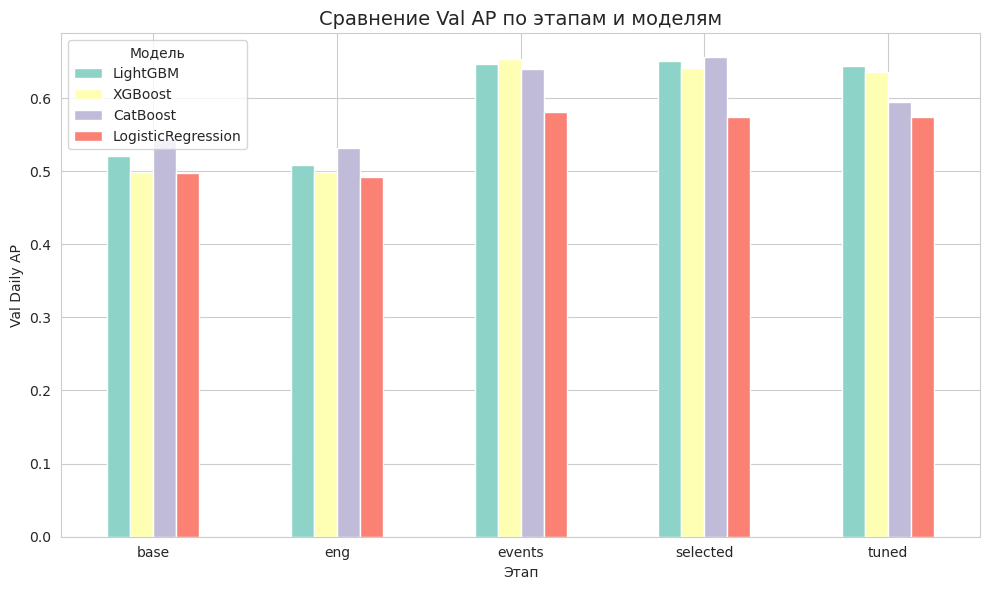

In [62]:
# Сравнение Val AP по этапам и моделям
df_vis = df_metrics.copy()
pivot_val = df_vis.pivot(index="Этап", columns="Модель", values="Val Daily AP")
pivot_val = pivot_val[["LightGBM", "XGBoost", "CatBoost", "LogisticRegression"]]

plt.figure(figsize=(10, 6))
pivot_val.plot(kind="bar", ax=plt.gca())
plt.title("Сравнение Val AP по этапам и моделям", fontsize=14)
plt.ylabel("Val Daily AP")
plt.xlabel("Этап")
plt.xticks(rotation=0)
plt.legend(title="Модель")
plt.tight_layout()
plt.savefig("val_ap_comparison.png", dpi=150)
plt.show()

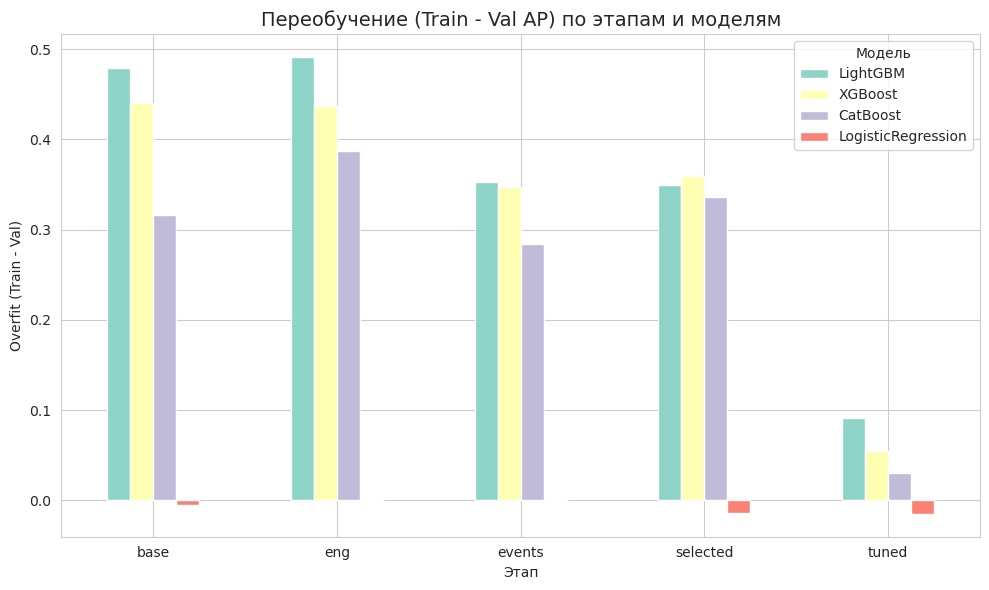

In [63]:
# Переобучение (Overfit) по этапам и моделям
df_vis["Overfit"] = df_vis["Train Daily AP"] - df_vis["Val Daily AP"]
pivot_overfit = df_vis.pivot(index="Этап", columns="Модель", values="Overfit")
pivot_overfit = pivot_overfit[["LightGBM", "XGBoost", "CatBoost", "LogisticRegression"]]

plt.figure(figsize=(10, 6))
pivot_overfit.plot(kind="bar", ax=plt.gca())
plt.title("Переобучение (Train - Val AP) по этапам и моделям", fontsize=14)
plt.ylabel("Overfit (Train - Val)")
plt.xlabel("Этап")
plt.xticks(rotation=0)
plt.legend(title="Модель")
plt.tight_layout()
plt.savefig("overfit_comparison.png", dpi=150)
plt.show()

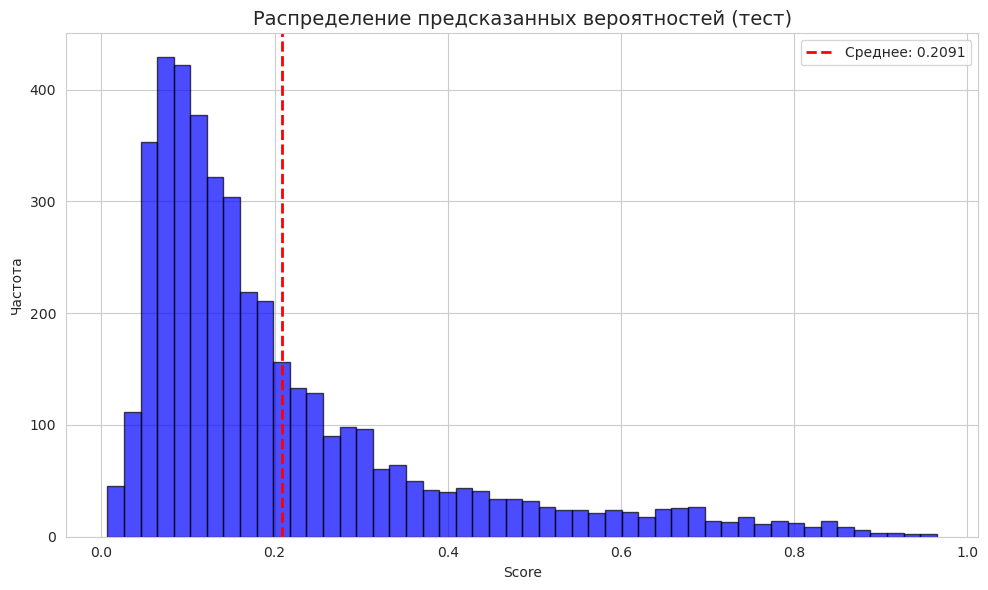

In [64]:
# Гистограмма предсказаний на тесте
plt.figure(figsize=(10, 6))
plt.hist(ensemble_test, bins=50, alpha=0.7, color="blue", edgecolor="black")
plt.title("Распределение предсказанных вероятностей (тест)", fontsize=14)
plt.xlabel("Score")
plt.ylabel("Частота")
plt.axvline(
    ensemble_test.mean(),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"Среднее: {ensemble_test.mean():.4f}",
)
plt.legend()
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150)
plt.show()